# SmartUncertALFrame：智能不确定性主动学习框架  demo

## 导入openmmlab算法库


>  - **mmengine**  
>       **深度学习训练引擎**，提供参数管理、优化器集成、训练循环搭建及日志记录与可视化等功能，助力模型训练与评估。
>  - **mmcv**  
>       为计算机视觉任务提供基础组件与工具，涵盖***数据预处理、图像增强、模型组件实现以及模型并行与加速***等功能，推动计算机视觉模型开发。
>  - **mmdet**  
>       基于 PyTorch 的目标检测开源框架，集成多类目标检测算法，具备***数据处理加载、模型训练评估及部署支持***等能力，便于目标检测模型的构建与应用。



In [1]:
# 使用示例
from mmdet.apis import init_detector, inference_detector
from sual.core.uncertainty.metrics import UncertaintyMetrics

from mmdet.apis import init_detector, inference_detector
from mmdet.utils import register_all_modules
from mmdet.registry import VISUALIZERS
import mmcv

## 加载配置文件和模型权重


In [2]:
# # download the checkpoint demo
# !mim download mmdet --config rtmdet_tiny_8xb32-300e_coco --dest ./checkpoints
config_file = '../work_dirs/retinanet_ssc_16_200/round_16/retinanet_ssc_16_200.py'
checkpoint_file = '../work_dirs/retinanet_ssc_16_200/round_16/epoch_3.pth'
# config_file = '../work_dirs/cascade-rcnn_ssc_16_200/round_16/cascade-rcnn_ssc.py'
# checkpoint_file = '../work_dirs/cascade-rcnn_ssc_16_200/round_16/epoch_3.pth'



## 注册所有模块和推理器


In [3]:
#Register all modules in mmdet into the registries
register_all_modules()
# build the model from a config file and a checkpoint file
model = init_detector(config_file, checkpoint_file, device='cuda:0')  # or device='cpu'

Loads checkpoint by local backend from path: ../work_dirs/retinanet_ssc_16_200/round_16/epoch_3.pth


## 推理预测图片

- mmdet模型推理结果为一个DetDataSample数据结构



In [4]:
# test a single image
from sual.apis import sual_inference_detector
img = mmcv.imread( '../data/ForestDamages/val2024/B_O_1f5aaba9_0088.jpg', channel_order='rgb')
result = inference_detector(model, img)

# Show the structure of result dict

print("all_scores exists:", hasattr(result.pred_instances, 'all_scores'))
print("scores:", hasattr(result.pred_instances, 'scores'))
from rich.pretty import pprint
pprint(result, max_length=4)

all_scores exists: True
scores: True


<DetDataSample(
│   
│   META INFORMATION
│   scale_factor: (0.8333333333333334, 0.8333333333333334)
│   img_id: 0
│   img_path: None
│   pad_shape: (1280, 1280)
│   batch_input_shape: (1280, 1280)
│   img_shape: (1280, 1280)
│   ori_shape: (1536, 1536)
│   
│   DATA FIELDS
│   pred_instances: <InstanceData(
│   │   │   
│   │   │   META INFORMATION
│   │   │   
│   │   │   DATA FIELDS
│   │   │   scores: tensor([0.8233, 0.8048, 0.7385, 0.7234, 0.7224, 0.7135, 0.7060, 0.6985, 0.6836,
│   │   │   │   │   │   0.6800, 0.6565, 0.6424, 0.6362, 0.5633, 0.5621, 0.5135, 0.5100, 0.4992,
│   │   │   │   │   │   0.4984, 0.4931, 0.4822, 0.4793, 0.4538, 0.4417, 0.4321, 0.4311, 0.3661,
│   │   │   │   │   │   0.3586, 0.3508, 0.3478, 0.3406, 0.3291, 0.3170, 0.3155, 0.3149, 0.3140,
│   │   │   │   │   │   0.3115, 0.3100, 0.3095, 0.3093, 0.2952, 0.2908, 0.2814, 0.2791, 0.2780,
│   │   │   │   │   │   0.2743, 0.2655, 0.2630, 0.2418, 0.2376, 0.2260, 0.2240, 0.2147, 0.2072,
│   │   │   │   │   │   0.1973, 0.1923, 0.1856, 0.1851, 0.1815, 0.1799, 0.1722, 0.1649, 0.1579,
│   │   │   │   │   │   0.1557, 0.1516, 0.1493, 0.1484, 0.1470, 0.1457, 0.1457, 0.1445, 0.1404,
│   │   │   │   │   │   0.1382, 0.1379, 0.1365, 0.1333, 0.1307, 0.1278, 0.1267, 0.1255, 0.1245,
│   │   │   │   │   │   0.1244, 0.1239, 0.1220, 0.1201, 0.1188, 0.1183, 0.1178, 0.1164, 0.1149,
│   │   │   │   │   │   0.1148, 0.1131, 0.1118, 0.1115, 0.1111, 0.1110, 0.1101, 0.1091, 0.1081,
│   │   │   │   │   │   0.1062, 0.1060, 0.1058, 0.1045, 0.1039, 0.1005, 0.0994, 0.0993, 0.0993,
│   │   │   │   │   │   0.0992, 0.0988, 0.0987, 0.0979, 0.0977, 0.0956, 0.0926, 0.0866],
│   │   │   │   │      device='cuda:0')
│   │   │   bboxes: tensor([[5.9063e+02, 8.7076e+02, 8.6842e+02, 1.2041e+03],
│   │   │   │   │   │   [1.0837e+02, 3.9815e+02, 3.1838e+02, 8.5921e+02],
│   │   │   │   │   │   [6.0684e+02, 0.0000e+00, 8.0627e+02, 3.9513e+02],
│   │   │   │   │   │   [6.6427e+02, 1.1670e+03, 8.3654e+02, 1.4783e+03],
│   │   │   │   │   │   [0.0000e+00, 7.6388e+02, 3.8582e+02, 1.3808e+03],
│   │   │   │   │   │   [7.9959e+02, 9.6288e+01, 1.0761e+03, 8.3035e+02],
│   │   │   │   │   │   [1.4282e+02, 1.2978e+03, 3.0856e+02, 1.5360e+03],
│   │   │   │   │   │   [9.0799e+02, 1.2002e+03, 1.1533e+03, 1.5360e+03],
│   │   │   │   │   │   [4.6248e+02, 2.8332e+02, 6.4298e+02, 6.9019e+02],
│   │   │   │   │   │   [5.4061e+02, 1.2262e+03, 6.9002e+02, 1.4552e+03],
│   │   │   │   │   │   [6.7555e+02, 4.7201e+02, 8.3138e+02, 9.0010e+02],
│   │   │   │   │   │   [9.6032e+02, 6.1517e+02, 1.1347e+03, 1.0306e+03],
│   │   │   │   │   │   [1.0478e+02, 0.0000e+00, 3.5183e+02, 3.1644e+02],
│   │   │   │   │   │   [8.0724e+02, 1.1448e+03, 1.0160e+03, 1.5026e+03],
│   │   │   │   │   │   [1.3485e+03, 6.6644e+01, 1.5305e+03, 6.3577e+02],
│   │   │   │   │   │   [1.0606e+03, 5.0131e+01, 1.2086e+03, 5.6562e+02],
│   │   │   │   │   │   [2.8671e+02, 3.7713e+02, 4.5735e+02, 8.9695e+02],
│   │   │   │   │   │   [6.1670e+02, 3.7077e+02, 7.7190e+02, 8.3463e+02],
│   │   │   │   │   │   [4.0191e+02, 5.2153e+01, 5.5709e+02, 3.1284e+02],
│   │   │   │   │   │   [3.6659e+02, 2.4527e+02, 4.9032e+02, 6.3262e+02],
│   │   │   │   │   │   [7.5109e+01, 1.9500e+02, 2.0803e+02, 4.2697e+02],
│   │   │   │   │   │   [1.1212e+03, 8.2047e+01, 1.2921e+03, 5.1757e+02],
│   │   │   │   │   │   [4.6230e+02, 6.0093e+02, 5.9251e+02, 8.6301e+02],
│   │   │   │   │   │   [1.9008e+02, 9.6162e+02, 4.0360e+02, 1.3569e+03],
│   │   │   │   │   │   [3.5639e+02, 5.8839e+02, 4.8189e+02, 9.0320e+02],
│   │   │   │   │   │   [5.4227e+02, 3.0750e+02, 6.9395e+02, 7.6336e+02],
│   │   │   │   │   │   [1.2550e+03, 0.0000e+00, 1.4043e+03, 4.6231e+02],
│   │   │   │   │   │   [3.5537e+02, 8.6276e+02, 5.6194e+02, 1.1910e+03],
│   │   │   │   │   │   [3.9701e+02, 7.1989e+02, 5.1459e+02, 9.2053e+02],
│   │   │   │   │   │   [4.5084e+02, 5.9743e+02, 5.7508e+02, 8.6810e+02],
│   │   │   │   │   │   [3.4471e+02, 8.7350e+02, 5.4820e+02, 1.2075e+03],
│   │   │   │   │   │   [1.2

In [6]:
# 在 sual/core/uncertainty/metrics.py 中添加
import numpy as np
from typing import Dict

from mmdet.structures import DetDataSample

def mus_uncertainty(
    result: DetDataSample,
    theta: float = 0.1,
    eps: float = 1e-10
) -> Dict[str, float]:
    """
    计算混合不确定性得分（MUS）
    返回格式：{bbox_id: mus_score}
    """
    if not hasattr(result, 'pred_instances') or len(result.pred_instances) == 0:
        return {}
    
    pred = result.pred_instances
    scores = pred.scores.cpu().numpy()
    all_scores = pred.all_scores.cpu().numpy()
    N = len(scores)
    
    # 1. 图像级不确定性
    high_conf_mask = scores > theta
    if np.any(high_conf_mask):
        avg_high_conf = np.mean(scores[high_conf_mask])
        img_uncertainty = 1.0 - avg_high_conf
    else:
        img_uncertainty = 1.0  # 无高置信目标时设为最大值
    
    # 2. 目标级不确定性（熵）
    obj_uncertainties = -np.sum(all_scores * np.log(all_scores + eps), axis=1)
    
    # 3. 混合得分
    mus_scores = img_uncertainty * obj_uncertainties
    
    return {f"bbox_{i}": float(mus_scores[i]) for i in range(N)}

In [7]:
mus_uncertainty(result)

{'bbox_0': 0.5039368867874146,
 'bbox_1': 0.4668445885181427,
 'bbox_2': 0.4256654977798462,
 'bbox_3': 0.5529607534408569,
 'bbox_4': 0.5137721300125122,
 'bbox_5': 0.6328510046005249,
 'bbox_6': 0.5911963582038879,
 'bbox_7': 0.589109480381012,
 'bbox_8': 0.6735403537750244,
 'bbox_9': 0.5313177108764648,
 'bbox_10': 0.6741546988487244,
 'bbox_11': 0.6738378405570984,
 'bbox_12': 0.9664502143859863,
 'bbox_13': 0.5062922835350037,
 'bbox_14': 0.7958268523216248,
 'bbox_15': 0.6408608555793762,
 'bbox_16': 0.5398812294006348,
 'bbox_17': 0.5249649882316589,
 'bbox_18': 0.6858271360397339,
 'bbox_19': 0.7956339120864868,
 'bbox_20': 0.6808323860168457,
 'bbox_21': 0.8869666457176208,
 'bbox_22': 0.92841637134552,
 'bbox_23': 0.6134974360466003,
 'bbox_24': 0.7947423458099365,
 'bbox_25': 0.6226888298988342,
 'bbox_26': 0.9768379330635071,
 'bbox_27': 1.1355870962142944,
 'bbox_28': 0.753817617893219,
 'bbox_29': 0.9249444603919983,
 'bbox_30': 1.1075361967086792,
 'bbox_31': 0.90458911

In [10]:
import os
from pathlib import Path
import json
from typing import Dict, Optional


def get_dataset_stats(
    data_root: str,
    ann_file: str,
    data_prefix: Optional[Dict] = None,
    verbose: bool = True
) -> Dict:
    """获取当前数据集的统计信息，用于主动学习选择样本前的分析
    
    Args:
        data_root: 数据集根目录
        ann_file: 标注文件路径
        data_prefix: 数据前缀配置，包含图像路径等信息
        verbose: 是否打印详细信息
        
    Returns:
        Dict: 包含数据集统计信息的字典，通常包括：
            - labeled_images: 已标注图片数量
            - unlabeled_images: 未标注图片数量
            - total_images: 总图片数量
            - labeled_ratio: 已标注图片占比
            - labeled_annotations: 已标注目标框数量
            - category_distribution: 各类别分布
            - image_size_distribution: 图像尺寸分布
    """
    try:
        from sual.core.datasets import ActiveCocoDataset
    except ImportError:
        raise ImportError("请确保已安装sual包并正确导入ActiveCocoDataset类")

    # 创建数据集实例
    dataset = ActiveCocoDataset(
        data_root=data_root,
        ann_file=ann_file,
        data_prefix=data_prefix
    )
    
    # 获取数据集统计信息
    stats = dataset.get_dataset_stats()
    
    # 额外计算类别分布（如果ActiveCocoDataset不提供）
    if 'category_distribution' not in stats and os.path.exists(ann_file):
        try:
            with open(ann_file, 'r') as f:
                coco_data = json.load(f)
                
            # 计算类别分布
            category_counts = {}
            categories = {cat['id']: cat['name'] for cat in coco_data.get('categories', [])}
            
            for ann in coco_data.get('annotations', []):
                cat_id = ann['category_id']
                cat_name = categories.get(cat_id, f"未知类别({cat_id})")
                category_counts[cat_name] = category_counts.get(cat_name, 0) + 1
                
            stats['category_distribution'] = category_counts
        except Exception as e:
            print(f"计算类别分布时出错: {e}")
    
    # 打印详细信息
    if verbose:
        print("\n数据集统计信息:")
        print(f"已标注图片数: {stats.get('labeled_images', 'N/A')}")
        print(f"未标注图片数: {stats.get('unlabeled_images', 'N/A')}")
        print(f"总图片数: {stats.get('total_images', 'N/A')}")
        print(f"标注比例: {stats.get('labeled_ratio', 0):.2%}")
        print(f"已标注框数量: {stats.get('labeled_annotations', 'N/A')}")
        
        # 打印类别分布（如果有）
        if 'category_distribution' in stats:
            print("\n类别分布:")
            for cat, count in stats['category_distribution'].items():
                print(f"  - {cat}: {count}")
    
    return stats


# 使用示例:
if __name__ == "__main__":
    # 以下参数需要根据实际情况修改
    stats = get_dataset_stats(
        data_root="../data/ForestDamages/active_learning_cascade_margin",
        ann_file="../data/ForestDamages/active_learning_cascade_margin/annotations/instances_unlabeled.json",
        data_prefix={"img":'../data/ForestDamages/active_learning_cascade_margin/images_unlabeled'}
    )
    
    # 您可以进一步分析或使用这些统计信息
    labeled_ratio = stats['labeled_ratio']
    print(f"\n当前已标注比例: {labeled_ratio:.2%}")
    # active_learning = dict(
    # data_root='data/ForestDamages/active_learning_cascade_margin',
    # ann_file='data/ForestDamages/active_learning_cascade_margin/annotations/instances_unlabeled.json',
    # data_prefix=dict(img='data/ForestDamages/active_learning_cascade_margin/images_unlabeled'),
    # 可以基于这些统计信息来调整采样策略
    if labeled_ratio < 0.2:
        print("建议使用随机采样策略")
    elif labeled_ratio < 0.5:
        print("建议使用不确定性采样策略")
    else:
        print("建议使用多样性采样策略")

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


ValueError: need at least one array to concatenate

In [13]:
# 验证多类别概率信息
import torch
def verify_cls_probs(result):
    pred_instances = result.pred_instances
    labels = pred_instances.labels.cpu()
    scores = pred_instances.scores.cpu()
    all_probs = pred_instances.all_cls_probs.cpu()
    
    print(f"检测框数量: {len(labels)}")
    
    # 验证每个框的最高概率类别是否与预测标签一致
    max_prob_labels = torch.argmax(all_probs, dim=1)
    match_count = (max_prob_labels == labels).sum().item()
    print(f"最高概率类别与预测标签匹配的框数量: {match_count}/{len(labels)}")
    
    # 验证最高概率值是否与预测分数一致
    max_probs, _ = torch.max(all_probs, dim=1)
    close_match = torch.isclose(max_probs, scores, atol=1e-5).sum().item()
    print(f"最高概率值与预测分数接近的框数量: {close_match}/{len(labels)}")
    
    # 检查是否有框具有多个显著类别概率
    multi_class_count = 0
    for i in range(len(labels)):
        # 获取除最高类别外的次高概率
        probs_except_max = all_probs[i].clone()
        max_idx = torch.argmax(probs_except_max)
        probs_except_max[max_idx] = 0
        second_max = torch.max(probs_except_max).item()
        
        if second_max > 0.2:  # 次高概率大于0.2视为显著
            multi_class_count += 1
            
            # 打印具有多个显著类别的框的信息
            if multi_class_count <= 3:  # 只显示前3个
                print(f"\n多类别框 #{i+1}:")
                print(f"预测类别: {labels[i].item()}, 置信度: {scores[i].item():.4f}")
                
                # 显示所有显著类别
                for cls_idx in range(all_probs.shape[1]):
                    prob = all_probs[i, cls_idx].item()
                    if prob > 0.2:
                        print(f"  类别 {cls_idx}: {prob:.4f}")
    
    print(f"\n具有多个显著类别概率(>0.2)的框数量: {multi_class_count}")
    
    # 计算熵不确定性
    entropy = -torch.sum(all_probs * torch.log(all_probs + 1e-10), dim=1)
    print(f"\n平均熵: {entropy.mean().item():.4f}")
    print(f"最大熵: {entropy.max().item():.4f}")
    
    # 显示熵最高的框
    top_entropy_idx = torch.argmax(entropy).item()
    print(f"\n熵最高的框 #{top_entropy_idx+1}:")
    print(f"预测类别: {labels[top_entropy_idx].item()}, 置信度: {scores[top_entropy_idx].item():.4f}")
    
    # 显示所有类别概率
    for cls_idx in range(all_probs.shape[1]):
        prob = all_probs[top_entropy_idx, cls_idx].item()
        if prob > 0.01:  # 只显示大于1%的概率
            print(f"  类别 {cls_idx}: {prob:.4f}")

# 测试
result_full = sual_inference_detector(model, img)
verify_cls_probs(result_full)

检测框数量: 300
最高概率类别与预测标签匹配的框数量: 300/300
最高概率值与预测分数接近的框数量: 300/300

具有多个显著类别概率(>0.2)的框数量: 0

平均熵: 0.3336
最大熵: 0.3679

熵最高的框 #2:
预测类别: 1, 置信度: 0.3668
  类别 1: 0.3668


## 不确定性采样器
>- 该模块用于主动学习中对未标注图片的**价值**进行度量，应当优先选择模型预测模糊的图片进行训练。

## 可视化

In [31]:
# init the visualizer(execute this block only once)
visualizer = VISUALIZERS.build(model.cfg.visualizer)
# the dataset_meta is loaded from the checkpoint and
# then pass to the model in init_detector
visualizer.dataset_meta = model.dataset_meta

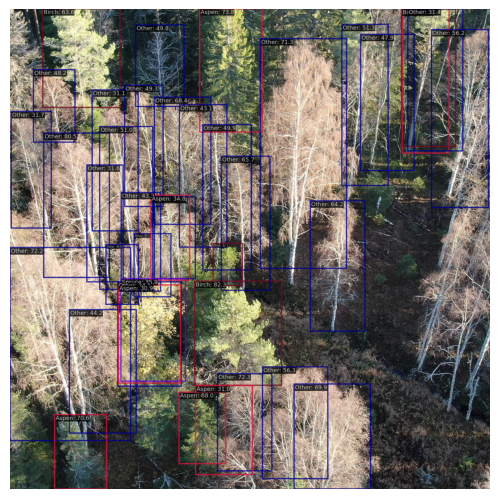

In [32]:
# show the results
visualizer.add_datasample(
    'result',
    img,
    data_sample=result,
    draw_gt=False,
    wait_time=0,
)
visualizer.show()

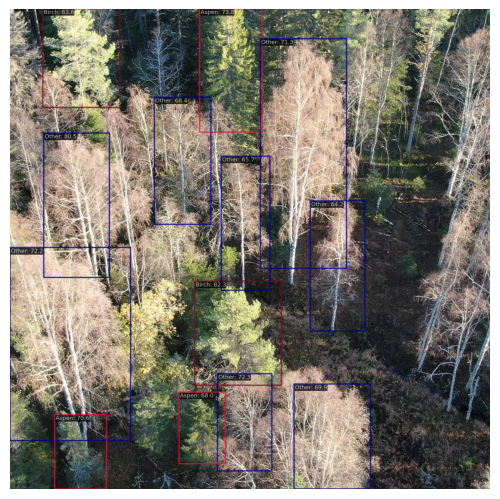

In [33]:
import warnings

# 全局忽略 UserWarning 类型的警告
warnings.simplefilter("ignore", UserWarning)

# 2. 设置很低的阈值来显示更多框
visualizer.add_datasample(
    'result',
    img,
    data_sample=result,
    draw_gt=False,
    wait_time=0,
    pred_score_thr=0.6,  # 设置很低的阈值
)
visualizer.show()

## 推理器 






- 批量对文件夹

In [ ]:
#  弃用留下仅作参考
# # 不使用不确定性度量模块
# !python -m sual.inference.detector \
#     ./checkpoints/config.py \
#     ./checkpoints/rtmdet_tiny.pth \
#     ./data/Eucalyptus_canopy/active_learning/images_labeled_val \
#     --device cuda:0 \
#     --batch-size 1 \
#     --num-workers 2 \
#     --use-fp16 \
#     --output-dir outputs \
#     --score-thr 0.3 \
#     --nms-thr 0.3 \
#     --max-det 100 \
#     --no-uncertainty \
#     --vis-scale 1.0

Loads checkpoint by local backend from path: ./checkpoints/rtmdet_tiny.pth
The model and loaded state dict do not match exactly

size mismatch for bbox_head.rtm_cls.0.weight: copying a param with shape torch.Size([80, 96, 1, 1]) from checkpoint, the shape in current model is torch.Size([1, 96, 1, 1]).
size mismatch for bbox_head.rtm_cls.0.bias: copying a param with shape torch.Size([80]) from checkpoint, the shape in current model is torch.Size([1]).
size mismatch for bbox_head.rtm_cls.1.weight: copying a param with shape torch.Size([80, 96, 1, 1]) from checkpoint, the shape in current model is torch.Size([1, 96, 1, 1]).
size mismatch for bbox_head.rtm_cls.1.bias: copying a param with shape torch.Size([80]) from checkpoint, the shape in current model is torch.Size([1]).
size mismatch for bbox_head.rtm_cls.2.weight: copying a param with shape torch.Size([80, 96, 1, 1]) from checkpoint, the shape in current model is torch.Size([1, 96, 1, 1]).
size mismatch for bbox_head.rtm_cls.2.bias: c


Processing images: 100%|██████████| 18/18 [00:04<00:00,  4.36it/s]


In [10]:
# 使用不确定性度量模块
!python -m sual.inference.detector \
    work_dirs\\newtest\\dino-5scale_swin-l\\dino-5scale_swin-l_forestdamage.py \
    work_dirs\\newtest\\dino-5scale_swin-l\\epoch_72.pth \
    raw \
    --device cuda:0 \
    --batch-size 8 \
    --num-workers 8 \
    --use-fp16 \
    --output-dir outputs \
    --score-thr 0.3 \
    --nms-thr 0.3 \
    --max-det 100 \
    --uncertainty-methods all \
    --vis-scale 1.0

Loads checkpoint by local backend from path: work_dirs\\newtest\\dino-5scale_swin-l\\epoch_72.pth
enable_uncertainty value: True

推理完成! 共处理 20 张图片
结果保存在: outputs/20250111_172129



Processing images: 100%|██████████| 20/20 [00:52<00:00,  2.61s/it]


- python api 实现


In [3]:
import torch
import asyncio
import nest_asyncio  # 添加这个导入
from pathlib import Path
from mmengine.config import Config
from mmdet.utils import register_all_modules

from sual.inference.detector import DetectionInference
from sual.core.datasets import ActiveCocoDataset

# 允许嵌套事件循环
nest_asyncio.apply()

async def async_active_learning_iteration():
    """异步主动学习迭代"""
    # 注册所有模块
    register_all_modules()
    
    # 配置文件和模型路径
    config_file = './checkpoints/config.py'
    checkpoint_file = './checkpoints/rtmdet_tiny.pth'
    
    # 数据集相关路径
    data_root = 'data/Eucalyptus_canopy'
    train_ann_file = 'data/Eucalyptus_canopy/active_learning/annotations/instances_labeled_train.json'
    img_prefix = 'data/Eucalyptus_canopy/active_learning/images_labeled_train'
    
    try:
        # 初始化检测器
        detector = DetectionInference(
            config_file=config_file,
            checkpoint_file=checkpoint_file,
            device='cuda:0',
            output_dir='outputs',
            enable_uncertainty=True,
            use_fp16=True,
            batch_size=2,
            max_memory_usage=0.7,
            cache_size=1000
        )
        
        # 初始化数据集
        dataset = ActiveCocoDataset(
            data_root=data_root,
            ann_file=train_ann_file,
            data_prefix={'img': img_prefix},
            pipeline=None
        )
        
        # 对未标注数据进行推理
        unlabeled_dir = Path(data_root) / 'active_learning/images_labeled_val'
        print(f"开始推理未标注数据: {unlabeled_dir}")
        
        # 直接调用异步推理方法
        results = await detector.async_inference(
            input_path=str(unlabeled_dir),
            score_thr=0.3,
            save_results=True,
            save_vis=True,
            vis_scale=1.0,
            uncertainty_methods=['entropy', 'variance']
        )
        
        print(f"推理完成，开始选择样本")
        
        # 选择样本
        selected_samples = dataset.select_samples(
            results=results,
            num_samples=10,
            strategy='uncertainty',
            uncertainty_method='entropy',
            min_score_thresh=0.3
        )
        
        # 更新数据集
        if selected_samples:
            success = dataset.update_dataset(selected_samples)
            print(f"数据集更新{'成功' if success else '失败'}")
            
        return selected_samples, results
        
    except Exception as e:
        print(f"发生错误: {str(e)}")
        raise

def run_active_learning():
    """运行主动学习迭代"""
    try:
        loop = asyncio.get_event_loop()
        return loop.run_until_complete(async_active_learning_iteration())
    except Exception as e:
        print(f"运行失败: {str(e)}")
        raise

# 如果在 Jupyter notebook 中运行
def run_in_notebook():
    return asyncio.get_event_loop().run_until_complete(async_active_learning_iteration())

if __name__ == '__main__':
    # 运行一次主动学习迭代
    try:
        selected_samples, results = run_active_learning()
        
        # 打印选中的样本
        print("\n选中的样本:")
        for sample in selected_samples:
            print(f"- {sample}")
        
        # 打印部分推理结果
        print("\n推理结果示例:")
        for img_name, info in list(results.items())[:3]:
            print(f"\n图片: {img_name}")
            result = info['result']
            print(f"检测到的目标数量: {len(result.pred_instances)}")
            if 'uncertainty' in info:
                print(f"不确定性指标: {info['uncertainty']}")
                
    except Exception as e:
        print(f"程序执行失败: {str(e)}")

Loads checkpoint by local backend from path: ./checkpoints/rtmdet_tiny.pth
enable_uncertainty value: True
loading annotations into memory...
Done (t=0.03s)
creating index...
index created!
开始推理未标注数据: data\Eucalyptus_canopy\active_learning\images_labeled_val


Processing images: 100%|██████████| 18/18 [00:06<00:00,  2.57it/s]
未找到选中样本的图片ID


推理完成，开始选择样本
数据集更新失败

选中的样本:
- 100_0001_0001_Cropped_13.jpg
- DJI_0195_Cropped_45.jpg
- DJI_0666_Cropped_1.jpg
- DJI_0108_Cropped_38.jpg
- DJI_0188_Cropped_69.jpg
- DJI_0186_Cropped_6.jpg
- DJI_0666_Cropped_13.jpg
- DJI_0801_Cropped_20.jpg
- DJI_0042_Cropped_24.jpg
- DJI_0193_Cropped_30.jpg

推理结果示例:

图片: 100_0001_0001_Cropped_13.jpg
检测到的目标数量: 300
不确定性指标: {'entropy': 5.699943542480469, 'normalized_entropy': 0.9993269497577927, 'variance': 0.0006229907157830894, 'std': 0.024959782138466835, 'cv': 0.034733505846283555}

图片: 100_0001_0181_Cropped_5.jpg
检测到的目标数量: 300
不确定性指标: {'entropy': 5.699913024902344, 'normalized_entropy': 0.9993215993472081, 'variance': 0.0006203523953445256, 'std': 0.02490687370300293, 'cv': 0.03456476533839048}

图片: DJI_0042_Cropped_24.jpg
检测到的目标数量: 300
不确定性指标: {'entropy': 5.7024126052856445, 'normalized_entropy': 0.9997598314141578, 'variance': 0.0002331643336219713, 'std': 0.015269719064235687, 'cv': 0.021527772289276943}


In [1]:
# import os

# def print_directory_structure(path, prefix="", output_file=None):
#     """
#     打印目录结构到文件或控制台
    
#     Args:
#         path: 要遍历的路径
#         prefix: 用于缩进的前缀
#         output_file: 输出文件对象，如果为None则打印到控制台
#     """
#     # 获取目录内容
#     contents = os.listdir(path)
#     # 分离文件和文件夹
#     folders = []
#     files = []
    
#     for item in contents:
#         item_path = os.path.join(path, item)
#         if os.path.isdir(item_path):
#             folders.append(item)
#         else:
#             files.append(item)
            
#     # 排序，使输出更有序
#     folders.sort()
#     files.sort()
    
#     # 打印文件夹
#     for folder in folders:
#         folder_path = os.path.join(path, folder)
#         line = f"{prefix}├── {folder}/"
#         if output_file:
#             output_file.write(line + "\n")
#         else:
#             print(line)
#         # 递归处理子文件夹，增加缩进
#         print_directory_structure(folder_path, prefix + "│   ", output_file)
    
#     # 打印文件
#     for i, file in enumerate(files):
#         # 最后一个项目使用└──，其他使用├──
#         connector = "└──" if i == len(files)-1 and not folders else "├──"
#         line = f"{prefix}{connector} {file}"
#         if output_file:
#             output_file.write(line + "\n")
#         else:
#             print(line)

# def main():
#     # 获取用户输入的路径
#     path = input("请输入要遍历的路径: ").strip()
#     output_path = input("请输入输出文件路径(直接回车打印到控制台): ").strip()
    
#     if not os.path.exists(path):
#         print("输入的路径不存在！")
#         return
        
#     if output_path:
#         with open(output_path, 'w', encoding='utf-8') as f:
#             print_directory_structure(path, output_file=f)
#         print(f"目录结构已保存到: {output_path}")
#     else:
#         print(f"\n{os.path.basename(path)}的目录结构：")
#         print_directory_structure(path)

# if __name__ == "__main__":
#     main()


的目录结构：
├── checkpoints/
│   ├── rtmdet_tiny_8xb32-300e_coco.py
│   └── rtmdet_tiny_8xb32-300e_coco_20220902_112414-78e30dcc.pth
├── mmdetection/
│   ├── .circleci/
│   │   ├── docker/
│   │   │   └── Dockerfile
│   │   ├── config.yml
│   │   ├── test.yml
│   ├── .dev_scripts/
│   │   ├── batch_test_list.py
│   │   ├── batch_train_list.txt
│   │   ├── benchmark_filter.py
│   │   ├── benchmark_full_models.txt
│   │   ├── benchmark_inference_fps.py
│   │   ├── benchmark_options.py
│   │   ├── benchmark_test.py
│   │   ├── benchmark_test_image.py
│   │   ├── benchmark_train.py
│   │   ├── benchmark_train_models.txt
│   │   ├── benchmark_valid_flops.py
│   │   ├── check_links.py
│   │   ├── convert_test_benchmark_script.py
│   │   ├── convert_train_benchmark_script.py
│   │   ├── covignore.cfg
│   │   ├── diff_coverage_test.sh
│   │   ├── download_checkpoints.py
│   │   ├── gather_models.py
│   │   ├── gather_test_benchmark_metric.py
│   │   ├── gather_train_benchmark_metric.py
│   │   ├──

## 配置文件组装器

- 将继承的文件保留，如datasets类型，models类型，schedules类型，default_runtime.py，结构清晰，适合对配置文件不熟悉


In [1]:
import os.path as osp
from sual.core.config import ConfigCopier

# 获取项目根目录
project_root = 'e:/开源编程项目/SUAL'

# 初始化配置复制器
copier = ConfigCopier(osp.join(project_root, 'mmdetection'))

# 指定保存目录
save_dir = osp.join(project_root, 'my_configs')

# 复制Faster R-CNN配置
config_path = copier.copy_config(
    algo_config='faster_rcnn/faster-rcnn_r50_fpn_1x_coco.py',
    save_dir=save_dir,
    save_name='my_faster_rcnn.py'
)


- 将所有的如datasets类型，models类型，schedules类型，default_runtime.py整合在一个配置py文件中，方便传输和复现


In [1]:
import os
import os.path as osp
from sual.core.config import ConfigMerger

# 获取项目根目录
project_root = 'e:/开源编程项目/SUAL'

# 初始化配置合并器
merger = ConfigMerger(osp.join(project_root, 'mmdetection'))

# 合并Faster R-CNN配置
config_path = merger.merge_config(
    algo_config='faster_rcnn/faster-rcnn_r50_fpn_1x_coco.py',
    save_path='my_configs/merged_faster_rcnn.py'
)

## 训练器

In [ ]:
# # 基本训练
# !python tools/train.py configs/my_config.py

# # 使用混合精度训练
# !python tools/train.py configs/my_config.py --amp

# # 指定工作目录
# !python tools/train.py configs/my_config.py --work-dir ./work_dirs/experiment1

# # 恢复训练
# !python tools/train.py configs/my_config.py --resume work_dirs/latest.pth

# # 覆盖配置选项
# !python tools/train.py configs/my_config.py --cfg-options model.backbone.depth=101 train_dataloader.batch_size=1

In [1]:
!python tools/train.py work_dirs\deformable-detr_r50_16xb2-50e_Eucalyptus_canopy\deformable-detr_r50_16xb2-50e_coco.py

11/30 19:10:07 - mmengine - INFO - 

Traceback (most recent call last):
  File "e:\SUAL\tools\train.py", line 165, in <module>
    main()
  File "e:\SUAL\tools\train.py", line 162, in main
    trainer.train()
  File "e:\SUAL\tools\train.py", line 116, in train
    runner.train()
  File "e:\sual\mmengine\mmengine\runner\runner.py", line 1748, in train
    self._init_model_weights()
  File "e:\sual\mmengine\mmengine\runner\runner.py", line 923, in _init_model_weights
    model.init_weights()
  File "e:\sual\mmdetection\mmdet\models\detectors\deformable_detr.py", line 103, in init_weights
    super().init_weights()
  File "e:\sual\mmengine\mmengine\model\base_module.py", line 136, in init_weights
    m.init_weights()
  File "e:\sual\mmengine\mmengine\model\base_module.py", line 144, in init_weights
    initialize(self, pretrained_cfg)
  File "e:\sual\mmengine\mmengine\model\weight_init.py", line 610, in initialize
    _initialize(module, cp_cfg)
  File "e:\sual\mmengine\mmengine\model\weight_init.py", line 518, in _initializ


------------------------------------------------------------
System environment:
    sys.platform: win32
    Python: 3.9.20 (main, Oct  3 2024, 07:38:01) [MSC v.1929 64 bit (AMD64)]
    CUDA available: True
    MUSA available: False
    numpy_random_seed: 202731467
    GPU 0: NVIDIA GeForce RTX 4090 D
    CUDA_HOME: C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v11.8
    NVCC: Cuda compilation tools, release 11.8, V11.8.89
    GCC: n/a
    PyTorch: 2.0.1+cu118
    PyTorch compiling details: PyTorch built with:
  - C++ Version: 199711
  - MSVC 193431937
  - Intel(R) Math Kernel Library Version 2020.0.2 Product Build 20200624 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v2.7.3 (Git Hash 6dbeffbae1f23cbbeae17adb7b5b13f1f37c080e)
  - OpenMP 2019
  - LAPACK is enabled (usually provided by MKL)
  - CPU capability usage: AVX2
  - CUDA Runtime 11.8
  - NVCC architecture flags: -gencode;arch=compute_37,code=sm_37;-gencode;arch=compute_50,code=sm_50;-gencode;arch=compute_

In [3]:
!python tools/train.py ./checkpoints/config.py

## 工具库

- 分析模型推理结果



In [4]:
!python tools/analyze_detection.py outputs\20241124_025230\results\000000026359_result.json --output-dir outputs/analyze_detection

成功设置中文字体

=== 基本检测统计 ===
总检测框数量: 300
置信度范围: 0.026 - 0.794
平均置信度: 0.053

=== 类别分布 (Top 5) ===
chair: 55 个 (18.3%)
keyboard: 33 个 (11.0%)
person: 33 个 (11.0%)
book: 29 个 (9.7%)
laptop: 28 个 (9.3%)

=== 置信度分布 ===
0.8-1.0: 0 个 (0.0%)
0.6-0.8: 2 个 (0.7%)
0.4-0.6: 0 个 (0.0%)
0.2-0.4: 3 个 (1.0%)
0.0-0.2: 295 个 (98.3%)

=== 边界框分析 ===
最小框面积: 432.4
最大框面积: 300524.1
平均框面积: 66021.7

=== 高置信度检测(>0.5)的类别分布 ===
cat: 1 个
laptop: 1 个

置信度分布图已保存至: outputs/analyze_detection\confidence_distribution.png
类别分布图已保存至: outputs/analyze_detection\class_distribution.png


- 分析模型推理的原始结果

In [12]:
!python tools/analyze_origin_det.py  ori_det\demo_raw.npz ori_det\demo_meta.json -o ori_det/analysis


=== 分析检测结果 ===
NPZ文件: ori_det\demo_raw.npz
Meta文件: ori_det\demo_meta.json

=== FPN特征分析 ===

fpn_fpn_level_0:
形状: (1, 96, 80, 80)
均值: 0.2263
标准差: 0.6255
最大值: 5.7003
最小值: -0.2785
激活通道数: 37

fpn_fpn_level_1:
形状: (1, 96, 40, 40)
均值: 0.4187
标准差: 0.8028
最大值: 9.0625
最小值: -0.2785
激活通道数: 52

fpn_fpn_level_2:
形状: (1, 96, 20, 20)
均值: 0.5722
标准差: 0.9643
最大值: 10.2324
最小值: -0.2785
激活通道数: 63

=== 分类分数分析 ===

cls_scores_level_0:
形状: (1, 80, 80, 80)
分数范围: -25.7537 - 0.8408
平均分数: -8.7529

该特征层置信度最高的5个类别:
类别 2 (car): 最高分数 = 0.8408
类别 13 (bench): 最高分数 = -0.1983
类别 56 (chair): 最高分数 = -0.3704
类别 7 (truck): 最高分数 = -0.7548
类别 16 (dog): 最高分数 = -1.3534

cls_scores_level_1:
形状: (1, 80, 40, 40)
分数范围: -38.2571 - 1.0829
平均分数: -10.0440

该特征层置信度最高的5个类别:
类别 2 (car): 最高分数 = 1.0829
类别 13 (bench): 最高分数 = 0.1612
类别 56 (chair): 最高分数 = -0.6436
类别 7 (truck): 最高分数 = -0.6544
类别 17 (horse): 最高分数 = -2.1084

cls_scores_level_2:
形状: (1, 80, 20, 20)
分数范围: -31.6938 - 2.0529
平均分数: -10.5058

该特征层置信度最高的5个类别:
类别 13 (bench): 最高分数 = 2.05

- 准备主动学习数据集 10%用于初始训练students模型，90%为未标注数据


In [1]:
!python tools/prepare_active_dataset.py \
    data/ForestDamages \
    data/ForestDamages/active_learning_ssc \
    --train-ratio 0.04 \
    --val-ratio 0.01 \
    --seed 42

合并数据集...
数据根目录: E:\SUAL\data\Eucalyptus_canopy
训练集标注文件: E:\SUAL\data\Eucalyptus_canopy\annotations\instances_train2017.json
验证集标注文件: E:\SUAL\data\Eucalyptus_canopy\annotations\instances_val2017.json
训练集图片目录: E:\SUAL\data\Eucalyptus_canopy\train2017
验证集图片目录: E:\SUAL\data\Eucalyptus_canopy\val2017
合并后总图像数: 912
合并后总标注数: 91270

数据集分割:
总样本数: 912
训练集大小: 72 (8.0%)
验证集大小: 18 (2.0%)
未标注集大小: 822 (90.0%)

处理 labeled_train 数据集...
从以下目录复制图片:
  - E:\SUAL\data\Eucalyptus_canopy\train2017
  - E:\SUAL\data\Eucalyptus_canopy\val2017
成功复制 72 张图片到 data\Eucalyptus_canopy\active_learning\images_labeled_train
保存标注到: data\Eucalyptus_canopy\active_learning\annotations\instances_labeled_train.json
图像数量: 72
标注数量: 7060

处理 labeled_val 数据集...
从以下目录复制图片:
  - E:\SUAL\data\Eucalyptus_canopy\train2017
  - E:\SUAL\data\Eucalyptus_canopy\val2017
成功复制 18 张图片到 data\Eucalyptus_canopy\active_learning\images_labeled_val
保存标注到: data\Eucalyptus_canopy\active_learning\annotations\instances_labeled_val.json
图像数量: 18
标注数量: 2293



- 验证主动学习数据集的规范性


In [1]:
!python tools/verify_active_dataset.py data/Eucalyptus_canopy/active_learning/annotations

找到 3 个JSON文件:
  - instances_labeled_train.json
  - instances_labeled_val.json
  - instances_unlabeled.json

验证 instances_labeled_train.json...

验证文件: instances_labeled_train.json
文件大小: 2.74 MB
处理时间: 0.02 秒

数据统计:
图像数量: 72
标注数量: 7060
类别数量: 1

每个类别的标注数量:
类别 0: 7060

验证 instances_labeled_val.json...

验证文件: instances_labeled_val.json
文件大小: 0.89 MB
处理时间: 0.01 秒

数据统计:
图像数量: 18
标注数量: 2293
类别数量: 1

每个类别的标注数量:
类别 0: 2293

验证 instances_unlabeled.json...

验证文件: instances_unlabeled.json
文件大小: 31.81 MB
处理时间: 0.30 秒

数据统计:
图像数量: 822
标注数量: 81917
类别数量: 1

每个类别的标注数量:
类别 0: 81917

📊 数据集总览:
总图像数量: 912
总标注数量: 91270
平均每张图片的标注数量: 100.08

✅ 验证通过: 所有文件都是有效的


## 主动学习数据集类

In [5]:
# from sual.core.datasets import ActiveCocoDataset
# import os.path as osp
# import os
# from sual.inference.detector import DetectionInference
# import json

# # 初始化推理器
# detector = DetectionInference(
#     config_file='./checkpoints/config.py',
#     checkpoint_file='./checkpoints/rtmdet_tiny.pth',
#     output_dir='./outputs',
#     enable_uncertainty=True  # 启用不确定性分析
# )


# # 在推理循环中，处理每张图片后释放未使用的内存
# try:
#     results = detector.inference(
#         'data/Eucalyptus_canopy/active_learning/images_labeled_val',
#         score_thr=0.3,
#         nms_thr=0.3,
#         max_det=100,
#         save_results=True,
#         save_vis=True,
#         vis_scale=0.8,
#         uncertainty_methods=['entropy']  # 指定不确定性计算方法
#     )

#     # 处理结果
#     for img_name, info in results.items():
#         print(f"\n处理图片: {img_name}")
        
#         # 访问不确定性指标
#         if info['uncertainty']:
#             print("不确定性指标:")
#             for metric, value in info['uncertainty'].items():
#                 if isinstance(value, (int, float)):
#                     print(f"- {metric}: {value:.4f}")

#         # 释放未使用的内存
#         torch.cuda.empty_cache()

#     # 结果保存位置
#     print(f"- 不确定性分析: {detector.uncertainty_dir}")
        
# except Exception as e:
#     print(f"推理失败: {e}")
# # 初始化数据集
# # 初始化数据集
# data_root = 'data/Eucalyptus_canopy/active_learning'
# ann_file = osp.join(data_root, 'annotations', 'instances_labeled_train.json')

# dataset = ActiveCocoDataset(
#     data_root=data_root,
#     ann_file=ann_file,
#     data_prefix={'img': 'images_labeled_train'}
# )

# # 使用推理结果选择样本
# selected_samples = dataset.select_samples(
#     results=results,
#     num_samples=100,
#     strategy='uncertainty',
#     uncertainty_method='entropy'
# )

# # 从未标注的 JSON 文件中提取新标注信息
# unlabeled_ann_file = osp.join(data_root, 'annotations/instances_unlabeled.json')
# with open(unlabeled_ann_file, 'r', encoding='utf-8') as f:
#     unlabeled_ann = json.load(f)

# # 提取选中样本的标注信息
# new_annotations = {
#     'images': [img for img in unlabeled_ann['images'] if img['file_name'] in selected_samples],
#     'annotations': [ann for ann in unlabeled_ann['annotations'] if ann['image_id'] in {img['id'] for img in unlabeled_ann['images'] if img['file_name'] in selected_samples}]
# }

# # 更新数据集
# dataset.update_dataset(
#     selected_samples=selected_samples,
#     new_annotations=new_annotations
# )

Loads checkpoint by local backend from path: ./checkpoints/rtmdet_tiny.pth
enable_uncertainty value: True


Processing images: 100%|██████████| 18/18 [00:03<00:00,  4.88it/s]


处理图片: 100_0001_0001_Cropped_13.jpg
不确定性指标:
- entropy: 5.6999
- normalized_entropy: 0.9993

处理图片: 100_0001_0181_Cropped_5.jpg
不确定性指标:
- entropy: 5.6999
- normalized_entropy: 0.9993

处理图片: DJI_0042_Cropped_24.jpg
不确定性指标:
- entropy: 5.7024
- normalized_entropy: 0.9998

处理图片: DJI_0047_Cropped_2.jpg
不确定性指标:
- entropy: 5.6946
- normalized_entropy: 0.9984

处理图片: DJI_0108_Cropped_38.jpg
不确定性指标:
- entropy: 5.7015
- normalized_entropy: 0.9996

处理图片: DJI_0186_Cropped_6.jpg
不确定性指标:
- entropy: 5.7016
- normalized_entropy: 0.9996

处理图片: DJI_0188_Cropped_69.jpg
不确定性指标:
- entropy: 5.7015
- normalized_entropy: 0.9996

处理图片: DJI_0193_Cropped_30.jpg
不确定性指标:
- entropy: 5.7026
- normalized_entropy: 0.9998

处理图片: DJI_0195_Cropped_45.jpg
不确定性指标:
- entropy: 5.7007
- normalized_entropy: 0.9995

处理图片: DJI_0195_Cropped_56.jpg
不确定性指标:
- entropy: 5.6981
- normalized_entropy: 0.9990

处理图片: DJI_0195_Cropped_66.jpg
不确定性指标:
- entropy: 5.6975
- normalized_entropy: 0.9989

处理图片: DJI_0228_Cropped_37.jpg
不确定性指标:
- entrop

TypeError: update_dataset() got an unexpected keyword argument 'new_annotations'

In [ ]:
# from collections import defaultdict
# from mmdet.datasets import CocoDataset
# from mmdet.registry import DATASETS
# import mmengine.fileio as fileio
# import json
# from datetime import datetime
# from pathlib import Path
# import shutil
# from sual.core.uncertainty.metrics import UncertaintyMetrics
# from mmdet.structures import DetDataSample

# @DATASETS.register_module()
# class ActiveCocoDataset(CocoDataset):
# 是继承自CocoDataset，这个主动学习的类，应该用函数如下
# 获取标注集中的训练和验证json文件，和获取未标注数据集的json文件，然后统计信息，如有多少个样本，多少个框，还有函数是通用的用于验证加载的json文件的规范性，，还应该有一个函数是不确定性模块


#数据集已经准备好了，接下来完成不确定性模块，现有的论文学者各有看法对于不确定性的度量，但是都是基于模型推理的原始结果，无非是，置信度和类别，但是这些不是最原始的模型推理结果，需要获取到mmdet模型推理的原始结果，如置信度是综合置信度，有类别置信度，如果有3个类，则每一个类别都有类别置信度，和物体存在置信度的乘积，乘积得到的才是综合置信度，只有获取到更原始的模型推理结果，我的框架才能将多个学者的不确定性度量方法进行全部封装，以上的信息是我剖析yolov5的代码得到的知识，但是对于mmdet有可能不是如此，所以接下来要对mmdet的mmdet\apis\det_inferencer.py和mmdet\apis\inference.py进行分析，修改源代码将更原始的模型推理结果输出，获得此结果，才能下一个不确定性模块的编写开发，

# 数据集已经准备好了，接下来完成不确定性模块，现有的论文学者各有看法对于不确定性的度量，但是都是基于模型推理的原始结果，无非是，置信度和类别，但是这些不是最原始的模型推理结果，需要获取到mmdet模型推理的原始结果，如置信度是综合置信度，有类别置信度，如果有3个类，则每一个类别都有类别置信度，和物体存在置信度的乘积，乘积得到的才是综合置信度，只有获取到更原始的模型推理结果，我的框架才能将多个学者的不确定性度量方法进行全部封装，以上的信息是我剖析yolov5的代码得到的知识，但是对于mmdet有可能不是如此，所以接下来要对mmdet的mmdet\apis\det_inferencer.py和mmdet\apis\inference.py进行分析，修改源代码将更原始的模型推理结果输出，获得此结果，才能下一个不确定性模块的编写开发，

In [9]:
import os
from typing import Dict, List, Union, Optional
from pathlib import Path

class FileScanner:
    """文件扫描器类"""
    
    def __init__(self, 
                 root_dir: Union[str, Path],
                 ignore_patterns: Optional[set] = None):
        """
        初始化扫描器
        
        Args:
            root_dir: 要扫描的根目录
            ignore_patterns: 要忽略的文件/目录模式
        """
        self.root_dir = Path(root_dir)
        self.ignore_patterns = ignore_patterns or {
            '.git', '__pycache__', '.pytest_cache', 
            '.vscode', '.idea', '*.pyc', '.DS_Store'
        }
        
    def _should_ignore(self, path: str) -> bool:
        """判断是否应该忽略该路径"""
        name = os.path.basename(path)
        # 检查是否以.开头
        if name.startswith('.'):
            return True
        # 检查是否在忽略列表中
        if name in self.ignore_patterns:
            return True
        # 检查是否匹配通配符模式
        for pattern in self.ignore_patterns:
            if '*' in pattern and name.endswith(pattern.replace('*', '')):
                return True
        return False
    
    def get_structure(self) -> Dict:
        """获取目录结构"""
        def _scan_dir(current_path: Path) -> Dict:
            result = {
                'type': 'directory',
                'name': current_path.name,
                'path': str(current_path.relative_to(self.root_dir)),
                'children': []
            }
            
            try:
                for item in current_path.iterdir():
                    if self._should_ignore(str(item)):
                        continue
                        
                    if item.is_file():
                        result['children'].append({
                            'type': 'file',
                            'name': item.name,
                            'path': str(item.relative_to(self.root_dir)),
                            'extension': item.suffix
                        })
                    elif item.is_dir():
                        result['children'].append(_scan_dir(item))
                        
                result['children'].sort(key=lambda x: x['name'])
                
            except PermissionError:
                print(f"警告: 无法访问目录 {current_path}")
                
            return result
        
        return _scan_dir(self.root_dir)
    
    def get_all_files(self) -> List[str]:
        """获取所有文件路径列表"""
        all_files = []
        
        def _collect_files(structure: Dict):
            if structure['type'] == 'file':
                all_files.append(structure['path'])
            elif structure['type'] == 'directory':
                for child in structure['children']:
                    _collect_files(child)
        
        _collect_files(self.get_structure())
        return all_files
    
    def get_files_by_extension(self, extension: str) -> List[str]:
        """
        获取指定扩展名的文件列表
        
        Args:
            extension: 文件扩展名（如 '.py'）
        """
        return [f for f in self.get_all_files() if f.endswith(extension)]
    
    def print_structure(self, structure: Dict = None, level: int = 0) -> None:
        """打印目录结构"""
        if structure is None:
            structure = self.get_structure()
            
        prefix = '│   ' * (level - 1) + '├── ' if level > 0 else ''
        print(f"{prefix}{structure['name']}")
        
        if structure['type'] == 'directory' and 'children' in structure:
            for child in structure['children']:
                self.print_structure(child, level + 1)

In [10]:
# 创建扫描器实例
scanner = FileScanner("sual")

# 获取目录结构
structure = scanner.get_structure()

# 打印目录结构
scanner.print_structure()

# 获取所有Python文件
python_files = scanner.get_files_by_extension('.py')
print("\nPython文件列表：")
for file in python_files:
    print(file)

sual
├── __init__.py
├── apis
│   ├── __init__.py
├── core
│   ├── __init__.py
│   ├── config
│   │   ├── __init__.py
│   │   ├── config_copier.py
│   │   ├── config_merger.py
│   ├── datasets
│   │   ├── __init__.py
│   │   ├── activate_datasets.py
│   ├── hooks
│   │   ├── __init__.py
│   │   ├── active_learning_hooks.py
│   ├── uncertainty
│   │   ├── __init__.py
│   │   ├── metrics.py
├── inference
│   ├── __init__.py
│   ├── detector.py
├── setup.py
├── sual.egg-info
│   ├── PKG-INFO
│   ├── SOURCES.txt
│   ├── dependency_links.txt
│   ├── top_level.txt
├── tools
│   ├── analyze_detection.py
│   ├── analyze_origin_det.py
│   ├── analyze_uncertainty.py
│   ├── demo.json
│   ├── outputs
│   │   ├── analysis
│   │   │   ├── class_distribution.png
│   │   │   ├── cls_scores_analysis.png
│   │   │   ├── confidence_distribution.png
│   │   │   ├── fpn_fpn_level_0_analysis.png
│   │   │   ├── fpn_fpn_level_1_analysis.png
│   │   │   ├── fpn_fpn_level_2_analysis.png
│   │   ├── demo_meta.